# Colocalization on curved domain

Makes patterns, calculates colocalizations and analyzes the results for highly curved domains

Usage instructions

* Execute all cells of Initialization and General parameters and definitions sections in order
* Generate or read previously generated regions and patterns
    * If not generated already: Execute all cells from Make regions and Make point patterns sections in order
    * If exist: Execute Read patterns ... / Read patterns section
* Compute colocalizations
    * if not generated already: Execute cells from Calculate ... section
* Analyze colocalizations
    * Execute cells of interest from Analysis section
* Examine colocalization results in detail (few examples)
    * Execute cells of interest from Accessing colocalization results section
* Visualize patterns
    * Execute cells of interest from Visualize patterns section

## Initialization

In [1]:
import os
import sys
import itertools
import pathlib

import numpy as np
import scipy as sp
import pandas as pd 

import pyto
from pyto.io.pandas_io import PandasIO
import pyto.spatial.point_pattern as point_pattern
import pyto.spatial.coloc_functions as col_func
import pyto.spatial.coloc_theory as coloc_theory
from pyto.spatial.particle_sets import ParticleSets
from pyto.spatial.multi_particle_sets import MultiParticleSets
from pyto.spatial.coloc_plot import plot_p, plot_32_p, plot_data, plot_32_data, plot_multiple
from pyto.spatial.coloc_lite import ColocLite

# matplotlib 
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

# common
import common
from common import n_A, n_B, n_C
from common import rectangle_full_area

# convenience
#import ipdb
%autosave 0
sys.version

Autosave disabled


'3.11.10 | packaged by conda-forge | (main, Sep 10 2024, 11:01:28) [GCC 13.3.0]'

In [2]:
# Settings

# force showing all rows in a table (default 60 rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

# use tex
plt.rcParams['text.usetex'] = True

# np print
np.set_printoptions(legacy='1.25')

# set hostname
hostname = os.uname()[1]
print(f"Host: {hostname}")

Host: rauna


### Setup figures 

In [3]:
# Useful functions for figures

# set plot parameters
def set_plot(plot_type):
    
    # for making figures 
    if plot_type == 'figure_save':
        # for some reason need to repeat
        %matplotlib qt
        plt.rcParams['font.size'] = 16  
        %matplotlib qt
        plt.rcParams['font.size'] = 16
        plt.rcParams['lines.linewidth'] =  1
    
    # figure-like inline
    if plot_type == 'figure_inline':
        %matplotlib inline
        plt.rcParams['font.size'] = 16
    
    # standard inline
    if plot_type == 'inline':
        %matplotlib inline
        plt.rcParams["figure.figsize"] = [4.5, 3]


In [4]:
# choose figure type, uncomment one
#plot_type = 'figure_save' 
#plot_type = 'figure_inline'
plot_type = 'inline'

set_plot(plot_type)

# directory to save plots (only if plot_type = 'figure_save')
plot_root = os.path.join(
    pathlib.Path.home(), 'directory_to_save_plots')

## General parameters and definitions

In [5]:
# General params

# random number seed used to generate random patterns 
seed = 123456

# path to regions
region_path = 'regions/curved.mrc'

# path to particles (patterns) table
mps_path = 'particles_curved/mps.pkl'

# colocalization distance [nm]
distance = np.arange(1, 31)

# N simulations
n_simul = 20
#n_simul = 500

# colocalization name mode
name_mode = '_'

In [14]:
def make_region_from_grey(
    grey, shape, height, top_z, region_id, up_id, down_id, eps=1e-6):
    """Expands grey 2d image to 3d regions image.

    Arguments:
        - grey: (2d ndarray) xy representation of a curved thin region 
        where the z axes is encoded by grey values 
        - shape: shape of the resulting 3d image
        - height, top_z: height and positioning in z
        - region_id, up_id, down_id: the resulting 3D image label ids

    Returns: (ndarray) 3D image 
    """

    # initialize
    im_data = np.zeros(shape, dtype='int16')
    grey_min = grey.min()
    grey_max = grey.max()
    grey_diff = grey_max - grey_min
    z_lin = np.linspace(grey_min, grey_max+eps, height+1)

    # set region_id at single pixel for each x, y 
    for (x, y), value in np.ndenumerate(grey):
        bin_ind = np.digitize(value, z_lin) 
        z_min = np.round(
            top_z - height 
            + (z_lin[bin_ind-1]-grey_min) * height / grey_diff).astype(int)
        z_max = np.round(
            top_z - height 
            + (z_lin[bin_ind]-grey_min) * height / grey_diff).astype(int)
        im_data[x, y, z_min:z_max] = region_id
        im_data[x, y, :z_min] = down_id
        im_data[x, y, z_max:] = up_id

    # make region continuous
    up_data = im_data==up_id
    dilated = sp.ndimage.binary_dilation(up_data)
    thin = dilated & np.invert(up_data)
    im_data[thin] = region_id

    return im_data
    
def make_region_at_distance(
    region, distance, region_id, other_id, offset=0.5):
    """Makes a region at a distance from an existing one.

    Aguments:
        - region: (3d ndimage) initial region image
        - region_id: id of the existing region
        - other_id: id of the part outsied of the existing region
        where the new region is made
        - offset: calculation offset (should be left at default)

    Returns: (ndimage) new region image 
    """

    dist_field = sp.ndimage.distance_transform_edt(region != region_id)
    region_new = (
        (dist_field >= distance - 0.5) & (dist_field < distance + 0.5)
        & (region == other_id)).astype('int16') * region_id

    return region_new

## Make regions 

In [10]:
# Patterns and regions parameters

# region images
region_id_up = 2
region_id_down = 1

# pixel size in nm
pixel_size_nm = 1

# region dimensions
region_height = 200
region_top_z = 250
region_shape = (600, 400, 300)
above_id = 5
below_id = 4
region_distance = 10

# exclusion distance [pixels]
exclusion = 5

# Make region images, needed for simulations only
#region_data = np.zeros((600, 500, 50), dtype=np.int16)

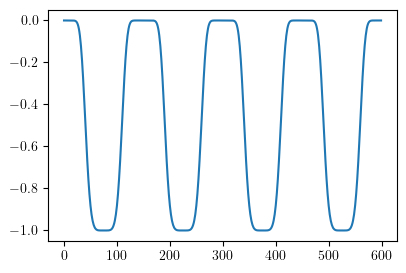

In [11]:
# make a deep curve, just to check how it looks

x_range = np.arange(600, dtype='int')
z = np.array([
    -(1 - np.cos(2*np.pi*x/300)**6)**8
    for x in x_range])

fig, ax = plt.subplots()
ax.plot(x_range, z);

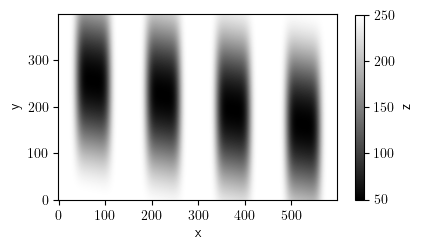

In [12]:
# make 2d regions template where z is encoded by greyscale 

x_range = np.arange(600, dtype='int')
y_range = np.arange(400, dtype='int')
z = np.zeros((600, 400))

x_len = len(x_range)

xx, yy = np.meshgrid(x_range, y_range, indexing='ij')
zz = -((1 - np.cos(2*np.pi*xx/300)**6)**8 
      * np.sin(2*np.pi*yy/1000 + (np.pi/4)*((xx-x_len/6)/x_len) )**2) 
zz = region_height * zz + region_top_z

fig, ax = plt.subplots()
#imsh = ax.imshow(zz.transpose(), cmap='grey', origin='lower', vmin=-1, vmax=0)
imsh = ax.imshow(
    zz.transpose(), cmap='grey', origin='lower', vmin=region_top_z-region_height, 
    vmax=region_top_z)
ax.set_xlabel('x')
ax.set_ylabel('y')
#fig.colorbar(imsh, ax=ax, label='z', shrink=0.8)
fig.colorbar(imsh, ax=ax, label='z', ticks=range(50, 251, 50), shrink=0.8)

if plot_type == 'figure_save':
    plt.savefig(plot_root + 'curved_grey.svg')

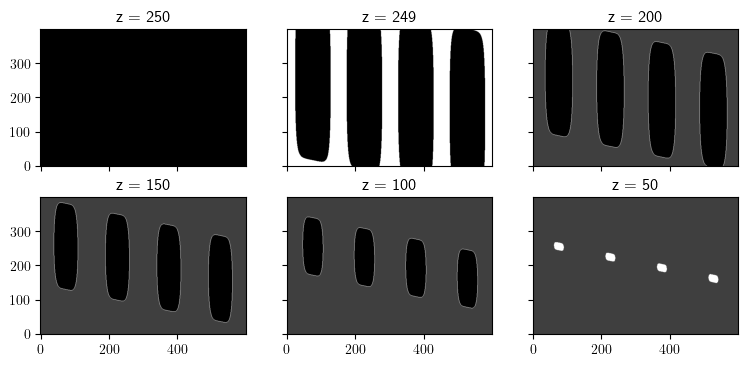

In [15]:
# make real (3d) regions image and show z slices

# make one region
im_data_down = make_region_from_grey(
    grey=zz, shape=region_shape, height=region_height, top_z=region_top_z, 
    region_id=region_id_down, up_id=above_id, down_id=below_id)

# show
planes = [250, 249, 200, 150, 100, 50]
n_cols = 3
row_height = 2

n_rows = (len(planes) - 1) // n_cols + 1
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(9, n_rows*row_height), sharex=True, sharey=True)
for ax, plan in zip(axes.flat, planes):
    ax.imshow(im_data_down[:, :, plan].transpose(), cmap='binary', origin='lower',
             vmin=region_id_down, vmax=above_id)
    ax.set_title(f'z = {plan}')

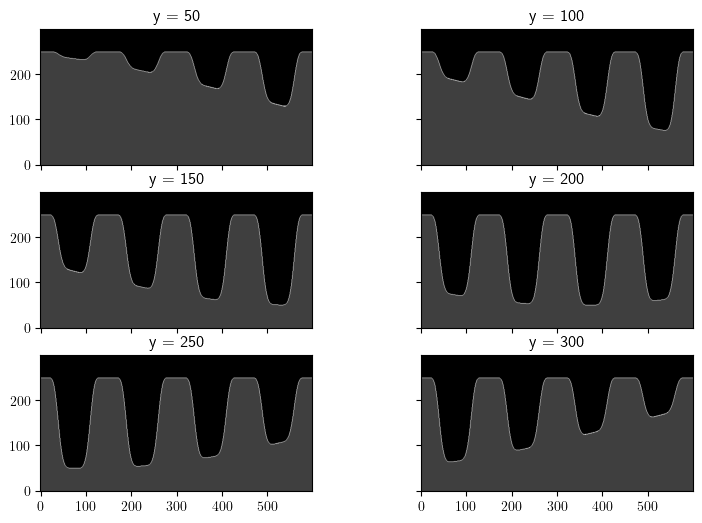

In [16]:
planes = range(50, 301, 50)
n_cols = 2
row_height = 2

n_rows = (len(planes) - 1) // n_cols + 1
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(9, n_rows*row_height), sharex=True, sharey=True)
for ax, plan in zip(axes.flat, planes):
    ax.imshow(im_data_down[:, plan, :].transpose(), cmap='binary', origin='lower')
    ax.set_title(f'y = {plan}')

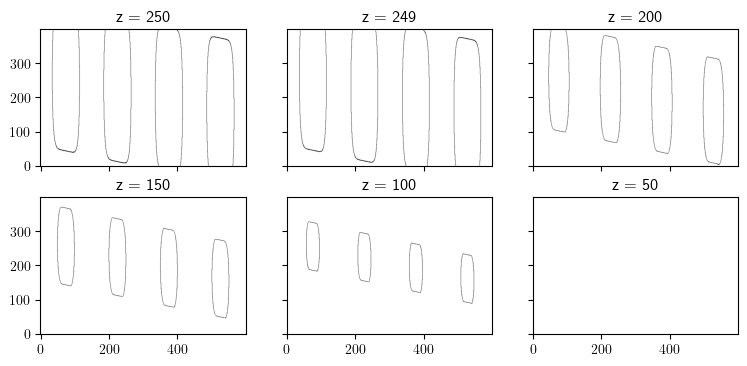

In [17]:
# make another region

im_data_up = make_region_at_distance(
    region=im_data_down, distance=region_distance, region_id=1, other_id=above_id)

# show
planes = [250, 249, 200, 150, 100, 50]
n_cols = 3
row_height = 2

n_rows = (len(planes) - 1) // n_cols + 1
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(9, n_rows*row_height), sharex=True, sharey=True)
for ax, plan in zip(axes.flat, planes):
    ax.imshow(im_data_up[:, :, plan].transpose(), cmap='binary', origin='lower')
    ax.set_title(f'z = {plan}')

In [13]:
# combine regions and save

im_data_down[im_data_down == above_id] = 0
im_data_down[im_data_down == below_id] = 0
im_data_up = region_id_up * im_data_up  
im_data = im_data_down + im_data_up

im = pyto.segmentation.Labels(data=im_data)
im.write(file=region_path)

<_io.BufferedWriter name='regions/curved.mrc'>

## Make point patterns

### Initialization

In [18]:
# Make region coordinates

im_data = pyto.core.Image.read(file=region_path)

coords_down_full = point_pattern.get_region_coords(
    region=im_data, region_id=region_id_down, shuffle=True, seed=seed)
coords_up_full = point_pattern.get_region_coords(
    region=im_data, region_id=region_id_up, shuffle=True, seed=seed)
print(f"N voxels down {coords_down_full.shape[0]}, up {coords_up_full.shape[0]}")

N voxels down 528120, up 544383


In [19]:
# set N particles at the same density as A and B
n_S = coords_down_full.shape[0] * n_A // rectangle_full_area
n_T = coords_down_full.shape[0] * n_B // rectangle_full_area

n_S, n_T

(1980, 1650)

In [20]:
# Restrict regions to ~60%

# make regions and get coords
coords = coords_down_full
cond = (
    (coords[:, 0] >= 20) & (coords[:, 0] < 450) 
    & (coords[:, 1] >= 50) & (coords[:, 1] < 350))
coords_down_06 = coords[cond]

coords = coords_up_full
cond = (
    (coords[:, 0] >= 20) & (coords[:, 0] < 450) 
    & (coords[:, 1] >= 50) & (coords[:, 1] < 350))
coords_up_06 = coords[cond]

coords_down_06.shape[0] / coords.shape[0], coords_up_06.shape[0] / coords.shape[0]

(0.6053440316835758, 0.6222714522679804)

### Random 

In [21]:
# make tomos dataframe
mps = MultiParticleSets()
mps.tomos = pd.DataFrame(
    {mps.tomo_id_col: ['delta'], 
     mps.region_col: region_path,
     mps.pixel_nm_col: pixel_size_nm})

pat_Sd_random_full = point_pattern.random_region(
    N=n_S, region_coords=coords_down_full, shuffle=True, seed=seed)
pat_Su_random_full = point_pattern.random_region(
    N=n_S, region_coords=coords_up_full, shuffle=True, seed=seed+1)
pat_Tu_random_full = point_pattern.random_region(
    N=n_T, region_coords=coords_up_full, shuffle=True, seed=seed+2)
pat_Td_random_full = point_pattern.random_region(
    N=n_T, region_coords=coords_down_full, shuffle=True, seed=seed+3)

patterns_down = {
    'SdRandomFull': pat_Sd_random_full, 'TdRandomFull': pat_Td_random_full}
patterns_up = {
    'SuRandomFull': pat_Su_random_full, 'TuRandomFull': pat_Tu_random_full}

particles_local = mps.from_patterns(
    patterns=patterns_down, coord_cols=mps.coord_reg_frame_cols, tomo_id='delta', 
    region_id=region_id_down, pixel_size_nm=pixel_size_nm, update=False)
mps.particles = particles_local
mps.from_patterns(
    patterns=patterns_up, coord_cols=mps.coord_reg_frame_cols, tomo_id='delta', 
    region_id=region_id_up, pixel_size_nm=pixel_size_nm, update=True)


### Univariate

In [22]:
# Make patterns

pat_Sd_random_06 = point_pattern.random_region(
    N=n_S, region_coords=coords_down_06, shuffle=True, seed=seed+20)
pat_Su_random_06 = point_pattern.random_region(
    N=n_S, region_coords=coords_up_06, shuffle=True, seed=seed+21)
pat_Td_random_06 = point_pattern.random_region(
    N=n_T, region_coords=coords_down_06, shuffle=True, seed=seed)+22
pat_Tu_random_06 = point_pattern.random_region(
    N=n_T, region_coords=coords_up_06, shuffle=True, seed=seed+23)

patterns_down = {
    'SdRandom06': pat_Sd_random_06, 'TdRandom06': pat_Td_random_06}
patterns_up = {
    'SuRandom06': pat_Su_random_06, 'TuRandom06': pat_Tu_random_06}

mps.from_patterns(
    patterns=patterns_down, coord_cols=mps.coord_reg_frame_cols, tomo_id='delta', 
    region_id=region_id_down, pixel_size_nm=pixel_size_nm, update=True)
mps.from_patterns(
    patterns=patterns_up, coord_cols=mps.coord_reg_frame_cols, tomo_id='delta', 
    region_id=region_id_up, pixel_size_nm=pixel_size_nm, update=True)

### Local interaction

In [23]:
# B colocalized with the A mode kd, d=14 (sqrt(200))

# generate B interacting with A patterns
cases = [
    ('f', '', 'f', '', 0.7, 'kd', 14),
    ('f', '', 'f', '', 0.3, 'kd', 14),
    ('f', '', 'f', '', 0.2, 'kd', 14),
    ('f', '', 'f', '', 0.15, 'kd', 14),
    ('f', '', 'f', '', 0.1, 'kd', 14),
    #('08', '', '08', '', 0.7, 'kd', 14),
    #('08', '', '08', '', 0.3, 'kd', 14),
    #('08', '', '08', '', 0.2, 'kd', 14),
    #('08', '', '08', '', 0.1, 'kd', 14),
    ('06', '', '06', '', 0.7, 'kd', 14),
    ('06', '', '06', '', 0.3, 'kd', 14),
    ('06', '', '06', '', 0.2, 'kd', 14),
    ('06', '', '06', '', 0.15, 'kd', 14),
    ('06', '', '06', '', 0.1, 'kd', 14),
    #('05', '', '05', '', 0.7, 'kd', 14),
    #('05', '', '05', '', 0.3, 'kd', 14),
    #('05', '', '05', '', 0.2, 'kd', 14),
    #('05', '', '05', '', 0.1, 'kd', 14)
]
seed_start = seed + 100
size_format = {'f': 'Full'}
size_format_region = {'f': 'full'}
fraction_format = {
    1: '1', 0.7: '07', 0.3: '03', 0.2: '02', 0.15: '015',  0.1: '01', 'kd': 'kd'}
region_id_dict = {'down': 1, 'up': 2}
print("Generated patterns:")
for ind, (size_fixed, loc_fixed, size_coloc, loc_coloc, p_fixed, p_coloc, dist) in enumerate(cases):

    size_coloc_region_formatted = size_format_region.get(size_coloc)
    if size_coloc_region_formatted is None:
        size_coloc_region_formatted = size_coloc
    size_coloc_formatted = size_format.get(size_coloc)
    if size_coloc_formatted is None:
        size_coloc_formatted = size_coloc
    exec(f"region_coords = coords_{'up'}_{size_coloc_region_formatted}")
    col_name = (
            f"Tur{size_coloc}{loc_coloc}CoclustSdr{size_fixed}{loc_fixed}"
            + f"p{fraction_format[p_fixed]}-p{fraction_format[p_coloc]}-d{dist}")
    fixed_name = f'SdRandom{size_coloc_formatted}{loc_fixed}'

    mps.colocalize_pattern(
        fixed_name=fixed_name, n_colocalize=n_T, mode='kd', colocalize_name=col_name, 
        region_coords=region_coords, region_id=region_id_dict['up'], 
        fixed_region_coords=None, 
        fixed_fraction=p_fixed, colocalize_fraction=p_coloc, max_dist=dist, 
        update=True, keep_fixed=False, seed=seed_start+2*ind)
    print(f"\t{col_name}  (coloc with {fixed_name})")
print(f"Seeds used: {seed_start} - {seed_start+(2*ind+1)}")

Generated patterns:
	TurfCoclustSdrfp07-pkd-d14  (coloc with SdRandomFull)
	TurfCoclustSdrfp03-pkd-d14  (coloc with SdRandomFull)
	TurfCoclustSdrfp02-pkd-d14  (coloc with SdRandomFull)
	TurfCoclustSdrfp015-pkd-d14  (coloc with SdRandomFull)
	TurfCoclustSdrfp01-pkd-d14  (coloc with SdRandomFull)
	Tur06CoclustSdr06p07-pkd-d14  (coloc with SdRandom06)
	Tur06CoclustSdr06p03-pkd-d14  (coloc with SdRandom06)
	Tur06CoclustSdr06p02-pkd-d14  (coloc with SdRandom06)
	Tur06CoclustSdr06p015-pkd-d14  (coloc with SdRandom06)
	Tur06CoclustSdr06p01-pkd-d14  (coloc with SdRandom06)
Seeds used: 123556 - 123575


### Write 

In [24]:
# write particles
mps.write(mps_path)

Pickled  MPS object to particles_curved/mps.pkl


## Read patterns and glance at them

### Read patterns
Has to be executed for calculations analysis and visualization

In [14]:
# read particles
# Has to be executed if the previous section was not executed

mps = MultiParticleSets.read(mps_path)

Read  MPS object particles_curved/mps.pkl


### Glance at patterns

In [15]:
n_part = mps.particles.groupby(['tomo_id', 'subclass_name'])['pixel_nm'].count()
n_part

tomo_id  subclass_name                
delta    SdRandom06                       1980
         SdRandomFull                     1980
         SuRandom06                       1980
         SuRandomFull                     1980
         TdRandom06                       1650
         TdRandomFull                     1650
         TuRandom06                       1650
         TuRandomFull                     1650
         Tur06CoclustSdr06p01-pkd-d14     1650
         Tur06CoclustSdr06p015-pkd-d14    1650
         Tur06CoclustSdr06p02-pkd-d14     1650
         Tur06CoclustSdr06p03-pkd-d14     1650
         Tur06CoclustSdr06p07-pkd-d14     1650
         TurfCoclustSdrfp01-pkd-d14       1650
         TurfCoclustSdrfp015-pkd-d14      1650
         TurfCoclustSdrfp02-pkd-d14       1650
         TurfCoclustSdrfp03-pkd-d14       1650
         TurfCoclustSdrfp07-pkd-d14       1650
Name: pixel_nm, dtype: int64

In [27]:
mps.tomos

,tomo_id,region,pixel_nm
0,delta,regions/curved.mrc,1


In [28]:
mps.particles.head()

,tomo_id,region_id,pixel_nm,class_name,subclass_name,x_reg_frame,y_reg_frame,z_reg_frame,keep
0,delta,1,1,SdRandomFull,SdRandomFull,303,119,249,True
1,delta,1,1,SdRandomFull,SdRandomFull,419,256,234,True
2,delta,1,1,SdRandomFull,SdRandomFull,330,335,243,True
3,delta,1,1,SdRandomFull,SdRandomFull,523,143,52,True
4,delta,1,1,SdRandomFull,SdRandomFull,37,125,222,True


In [29]:
mps.particles.tail()

,tomo_id,region_id,pixel_nm,class_name,subclass_name,x_reg_frame,y_reg_frame,z_reg_frame,keep
31015,delta,2,1,Tur06CoclustSdr06p01-pkd-d14,Tur06CoclustSdr06p01-pkd-d14,186,232,248,True
31016,delta,2,1,Tur06CoclustSdr06p01-pkd-d14,Tur06CoclustSdr06p01-pkd-d14,432,108,259,True
31017,delta,2,1,Tur06CoclustSdr06p01-pkd-d14,Tur06CoclustSdr06p01-pkd-d14,190,303,241,True
31018,delta,2,1,Tur06CoclustSdr06p01-pkd-d14,Tur06CoclustSdr06p01-pkd-d14,316,62,259,True
31019,delta,2,1,Tur06CoclustSdr06p01-pkd-d14,Tur06CoclustSdr06p01-pkd-d14,251,136,187,True


In [30]:
mps.particles.query('class_name == "TurfCoclustSdrfp07-pkd-d14"').tail()

,tomo_id,region_id,pixel_nm,class_name,subclass_name,x_reg_frame,y_reg_frame,z_reg_frame,keep
16165,delta,2,1,TurfCoclustSdrfp07-pkd-d14,TurfCoclustSdrfp07-pkd-d14,59,30,257,True
16166,delta,2,1,TurfCoclustSdrfp07-pkd-d14,TurfCoclustSdrfp07-pkd-d14,106,233,209,True
16167,delta,2,1,TurfCoclustSdrfp07-pkd-d14,TurfCoclustSdrfp07-pkd-d14,109,131,242,True
16168,delta,2,1,TurfCoclustSdrfp07-pkd-d14,TurfCoclustSdrfp07-pkd-d14,396,121,137,True
16169,delta,2,1,TurfCoclustSdrfp07-pkd-d14,TurfCoclustSdrfp07-pkd-d14,335,223,250,True


In [31]:
mps.particles.query('class_name == "SdRandomFull"').head()

,tomo_id,region_id,pixel_nm,class_name,subclass_name,x_reg_frame,y_reg_frame,z_reg_frame,keep
0,delta,1,1,SdRandomFull,SdRandomFull,303,119,249,True
1,delta,1,1,SdRandomFull,SdRandomFull,419,256,234,True
2,delta,1,1,SdRandomFull,SdRandomFull,330,335,243,True
3,delta,1,1,SdRandomFull,SdRandomFull,523,143,52,True
4,delta,1,1,SdRandomFull,SdRandomFull,37,125,222,True


In [32]:
u2 = mps.get_region(tomo_id='delta', set_name='TuRandomFull')
d2 = mps.get_region(tomo_id='delta', set_name='SdRandomFull')
(d2 == 1).sum(), (u2 == 1).sum()


(528120, 544383)

## Calculate 2-colocalizations

### Random

In [16]:
# Colocalization

# colocalization name
coloc_name = 'SdRandomFull_TuRandomFull'

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: SdRandomFull_TuRandomFull
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/SdRandomFull_TuRandomFull/SdRandomFull_TuRandomFull.pkl
N particles initial (before exclusion):
    subclass_name  SdRandomFull  TuRandomFull
    tomo_id                                  
    delta                  1980          1650
    Total                  1980          1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/SdRandomFull_TuRandomFull/SdRandomFull_TuRandomFull.pkl
N particles after exclusion:
    subclass_name  SdRandomFull  TuRandomFull
    tomo_id                                  
    delta                  1980          1650
    Tota

In [17]:
# Colocalization

# colocalization name
coloc_name = 'TuRandomFull_SdRandomFull'

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: TuRandomFull_SdRandomFull
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/TuRandomFull_SdRandomFull/TuRandomFull_SdRandomFull.pkl
N particles initial (before exclusion):
    subclass_name  SdRandomFull  TuRandomFull
    tomo_id                                  
    delta                  1980          1650
    Total                  1980          1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/TuRandomFull_SdRandomFull/TuRandomFull_SdRandomFull.pkl
N particles after exclusion:
    subclass_name  SdRandomFull  TuRandomFull
    tomo_id                                  
    delta                  1980          1650
    Tota

### Univariate

In [18]:
# Colocalization

# colocalization name
coloc_name = 'SdRandom06_TuRandomFull'

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: SdRandom06_TuRandomFull
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/SdRandom06_TuRandomFull/SdRandom06_TuRandomFull.pkl
N particles initial (before exclusion):
    subclass_name  SdRandom06  TuRandomFull
    tomo_id                                
    delta                1980          1650
    Total                1980          1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/SdRandom06_TuRandomFull/SdRandom06_TuRandomFull.pkl
N particles after exclusion:
    subclass_name  SdRandom06  TuRandomFull
    tomo_id                                
    delta                1980          1650
    Total                1980   

In [19]:
# Colocalization

# colocalization name
coloc_name = 'TuRandomFull_SdRandom06'

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: TuRandomFull_SdRandom06
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/TuRandomFull_SdRandom06/TuRandomFull_SdRandom06.pkl
N particles initial (before exclusion):
    subclass_name  SdRandom06  TuRandomFull
    tomo_id                                
    delta                1980          1650
    Total                1980          1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/TuRandomFull_SdRandom06/TuRandomFull_SdRandom06.pkl
N particles after exclusion:
    subclass_name  SdRandom06  TuRandomFull
    tomo_id                                
    delta                1980          1650
    Total                1980   

### Global interaction

In [20]:
# Colocalization

# colocalization name
coloc_name = 'SdRandom06_TuRandom06'

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: SdRandom06_TuRandom06
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/SdRandom06_TuRandom06/SdRandom06_TuRandom06.pkl
N particles initial (before exclusion):
    subclass_name  SdRandom06  TuRandom06
    tomo_id                              
    delta                1980        1650
    Total                1980        1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/SdRandom06_TuRandom06/SdRandom06_TuRandom06.pkl
N particles after exclusion:
    subclass_name  SdRandom06  TuRandom06
    tomo_id                              
    delta                1980        1650
    Total                1980        1650


Processing t

In [21]:
# Colocalization

# colocalization name
coloc_name = 'TuRandom06_SdRandom06'

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: TuRandom06_SdRandom06
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/TuRandom06_SdRandom06/TuRandom06_SdRandom06.pkl
N particles initial (before exclusion):
    subclass_name  SdRandom06  TuRandom06
    tomo_id                              
    delta                1980        1650
    Total                1980        1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/TuRandom06_SdRandom06/TuRandom06_SdRandom06.pkl
N particles after exclusion:
    subclass_name  SdRandom06  TuRandom06
    tomo_id                              
    delta                1980        1650
    Total                1980        1650


Processing t

### Local interaction

In [67]:
# Colocalization

# colocalization name
coloc_name = 'SdRandomFull_TurfCoclustSdrfp03-pkd-d14' 

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: SdRandomFull_TurfCoclustSdrfp03-pkd-d14
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/SdRandomFull_TurfCoclustSdrfp03-pkd-d14/SdRandomFull_TurfCoclustSdrfp03-pkd-d14.pkl
N particles initial (before exclusion):
    subclass_name  SdRandomFull  TurfCoclustSdrfp03-pkd-d14
    tomo_id                                                
    delta                  1980                        1650
    Total                  1980                        1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/SdRandomFull_TurfCoclustSdrfp03-pkd-d14/SdRandomFull_TurfCoclustSdrfp03-pkd-d14.pkl
N particles after exclusion:
    subclass_name  S

In [68]:
# Colocalization

# colocalization name
coloc_name = 'TurfCoclustSdrfp03-pkd-d14_SdRandomFull' 

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: TurfCoclustSdrfp03-pkd-d14_SdRandomFull
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/TurfCoclustSdrfp03-pkd-d14_SdRandomFull/TurfCoclustSdrfp03-pkd-d14_SdRandomFull.pkl
N particles initial (before exclusion):
    subclass_name  SdRandomFull  TurfCoclustSdrfp03-pkd-d14
    tomo_id                                                
    delta                  1980                        1650
    Total                  1980                        1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/TurfCoclustSdrfp03-pkd-d14_SdRandomFull/TurfCoclustSdrfp03-pkd-d14_SdRandomFull.pkl
N particles after exclusion:
    subclass_name  S

In [22]:
# Colocalization 500 simul

# colocalization name
coloc_name = 'SdRandomFull_TurfCoclustSdrfp015-pkd-d14' 
n_simul_loc = 500

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_=f'coloc_curved_{n_simul_loc}')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul_loc)

Colocalization parameters:
    Colocalization name: SdRandomFull_TurfCoclustSdrfp015-pkd-d14
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved_500/input_particles/SdRandomFull_TurfCoclustSdrfp015-pkd-d14/SdRandomFull_TurfCoclustSdrfp015-pkd-d14.pkl
N particles initial (before exclusion):
    subclass_name  SdRandomFull  TurfCoclustSdrfp015-pkd-d14
    tomo_id                                                 
    delta                  1980                         1650
    Total                  1980                         1650
Pickled  MPS object to coloc_curved_500/after_exclusion_particles/SdRandomFull_TurfCoclustSdrfp015-pkd-d14/SdRandomFull_TurfCoclustSdrfp015-pkd-d14.pkl
N particles after exclusion:
   

In [23]:
# Colocalization 500 simulations

# colocalization name
coloc_name = 'TurfCoclustSdrfp015-pkd-d14_SdRandomFull' 
n_simul_loc = 500

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_=f'coloc_curved_{n_simul_loc}')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul_loc)

Colocalization parameters:
    Colocalization name: TurfCoclustSdrfp015-pkd-d14_SdRandomFull
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved_500/input_particles/TurfCoclustSdrfp015-pkd-d14_SdRandomFull/TurfCoclustSdrfp015-pkd-d14_SdRandomFull.pkl
N particles initial (before exclusion):
    subclass_name  SdRandomFull  TurfCoclustSdrfp015-pkd-d14
    tomo_id                                                 
    delta                  1980                         1650
    Total                  1980                         1650
Pickled  MPS object to coloc_curved_500/after_exclusion_particles/TurfCoclustSdrfp015-pkd-d14_SdRandomFull/TurfCoclustSdrfp015-pkd-d14_SdRandomFull.pkl
N particles after exclusion:
   

### Local and global interaction

In [25]:
# Colocalization

# colocalization name
coloc_name = 'SdRandom06_Tur06CoclustSdr06p03-pkd-d14' 

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: SdRandom06_Tur06CoclustSdr06p03-pkd-d14
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/SdRandom06_Tur06CoclustSdr06p03-pkd-d14/SdRandom06_Tur06CoclustSdr06p03-pkd-d14.pkl
N particles initial (before exclusion):
    subclass_name  SdRandom06  Tur06CoclustSdr06p03-pkd-d14
    tomo_id                                                
    delta                1980                          1650
    Total                1980                          1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/SdRandom06_Tur06CoclustSdr06p03-pkd-d14/SdRandom06_Tur06CoclustSdr06p03-pkd-d14.pkl
N particles after exclusion:
    subclass_name  S

In [26]:
# Colocalization

# colocalization name
coloc_name = 'Tur06CoclustSdr06p03-pkd-d14_SdRandom06' 

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: Tur06CoclustSdr06p03-pkd-d14_SdRandom06
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/Tur06CoclustSdr06p03-pkd-d14_SdRandom06/Tur06CoclustSdr06p03-pkd-d14_SdRandom06.pkl
N particles initial (before exclusion):
    subclass_name  SdRandom06  Tur06CoclustSdr06p03-pkd-d14
    tomo_id                                                
    delta                1980                          1650
    Total                1980                          1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/Tur06CoclustSdr06p03-pkd-d14_SdRandom06/Tur06CoclustSdr06p03-pkd-d14_SdRandom06.pkl
N particles after exclusion:
    subclass_name  S

In [24]:
# Colocalization

# colocalization name
coloc_name = 'SdRandom06_Tur06CoclustSdr06p015-pkd-d14' 

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: SdRandom06_Tur06CoclustSdr06p015-pkd-d14
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/SdRandom06_Tur06CoclustSdr06p015-pkd-d14/SdRandom06_Tur06CoclustSdr06p015-pkd-d14.pkl
N particles initial (before exclusion):
    subclass_name  SdRandom06  Tur06CoclustSdr06p015-pkd-d14
    tomo_id                                                 
    delta                1980                           1650
    Total                1980                           1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/SdRandom06_Tur06CoclustSdr06p015-pkd-d14/SdRandom06_Tur06CoclustSdr06p015-pkd-d14.pkl
N particles after exclusion:
    subclas

In [25]:
# Colocalization

# colocalization name
coloc_name = 'Tur06CoclustSdr06p015-pkd-d14_SdRandom06' 

# select particles 
set_names = col_func.get_names(coloc_name, mode=name_mode)
mps_local = mps.select(class_names=set_names, update=False)

# colocalize
col = ColocLite(dir_='coloc_curved')
col.colocalize(
    coloc_case=coloc_name, particles=mps_local, distance=distance,
    n_simul=n_simul)

Colocalization parameters:
    Colocalization name: Tur06CoclustSdr06p015-pkd-d14_SdRandom06
    Colocalization distance [nm]: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30 
    Calculate columns: True, columns distance factor 2
    Exclusion distance [nm]: None
    Make convex hull: False

Tomo pixel size [nm]
    delta: 1
Pickled  MPS object to coloc_curved/input_particles/Tur06CoclustSdr06p015-pkd-d14_SdRandom06/Tur06CoclustSdr06p015-pkd-d14_SdRandom06.pkl
N particles initial (before exclusion):
    subclass_name  SdRandom06  Tur06CoclustSdr06p015-pkd-d14
    tomo_id                                                 
    delta                1980                           1650
    Total                1980                           1650
Pickled  MPS object to coloc_curved/after_exclusion_particles/Tur06CoclustSdr06p015-pkd-d14_SdRandom06/Tur06CoclustSdr06p015-pkd-d14_SdRandom06.pkl
N particles after exclusion:
    subclas

## Analysis

### Read colocalizations

In [18]:
# Read colocalization results
# has to be executed every time

col = ColocLite.read_table_multi(
    names=None, dir_='coloc_curved', mode=name_mode, verbose=False)
col_500 = ColocLite.read_table_multi(
    names=None, dir_='coloc_curved_500', mode=name_mode, verbose=False)

### Check

In [19]:
col.data_names

['SdRandomFull_TurfCoclustSdrfp07-pkd-d14',
 'TuRandomFull_SdRandomFull',
 'SdRandom06_TuRandom06',
 'Tur06CoclustSdr06p03-pkd-d14_SdRandom06',
 'TurfCoclustSdrfp07-pkd-d14_SdRandomFull',
 'SdRandom06_TuRandomFull',
 'SdRandomFull_TuRandomFull',
 'SdRandomFull_TurfCoclustSdrfp03-pkd-d14',
 'TuRandom06_SdRandom06',
 'SdRandomFull_TurfCoclustSdrfp02-pkd-d14',
 'SdRandom06_Tur06CoclustSdr06p01-pkd-d14',
 'TuRandom06_SdRandomFull',
 'TurfCoclustSdrfp02-pkd-d14_SdRandomFull',
 'Tur06CoclustSdr06p01-pkd-d14_SdRandom06',
 'TurfCoclustSdrfp01-pkd-d14_SdRandomFull',
 'SdRandomFull_TurfCoclustSdrfp01-pkd-d14',
 'Tur06CoclustSdr06p015-pkd-d14_SdRandom06',
 'SdRandom06_Tur06CoclustSdr06p02-pkd-d14',
 'SdRandomFull_TuRandom06',
 'Tur06CoclustSdr06p02-pkd-d14_SdRandom06',
 'SdRandom06_Tur06CoclustSdr06p015-pkd-d14',
 'SdRandom06_Tur06CoclustSdr06p07-pkd-d14',
 'TuRandomFull_SdRandom06',
 'TurfCoclustSdrfp03-pkd-d14_SdRandomFull',
 'Tur06CoclustSdr06p07-pkd-d14_SdRandom06',
 'SdRandom06_Tur06CoclustS

In [20]:
col_500.data_names

['TurfCoclustSdrfp015-pkd-d14_SdRandomFull',
 'SdRandomFull_TurfCoclustSdrfp02-pkd-d14',
 'TurfCoclustSdrfp02-pkd-d14_SdRandomFull',
 'SdRandomFull_TurfCoclustSdrfp015-pkd-d14']

In [11]:
cols = ['distance', 'size_region', 'n_subcol', 
        'n_subcol_random_all', 'n_subcol_random_mean', 'n_subcol_random_std',
        'n_subcol_random_alt_all', 'n_subcol_random_alt_mean', 'n_subcol_random_alt_std']
col.SdRandomFull_TuRandomFull_data[cols].head()

,distance,size_region,n_subcol,n_subcol_random_all,n_subcol_random_mean,n_subcol_random_std,n_subcol_random_alt_all,n_subcol_random_alt_mean,n_subcol_random_alt_std
0,1,528120,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0
1,2,528120,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0
2,3,528120,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0
3,4,528120,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0
4,5,528120,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0


### Random

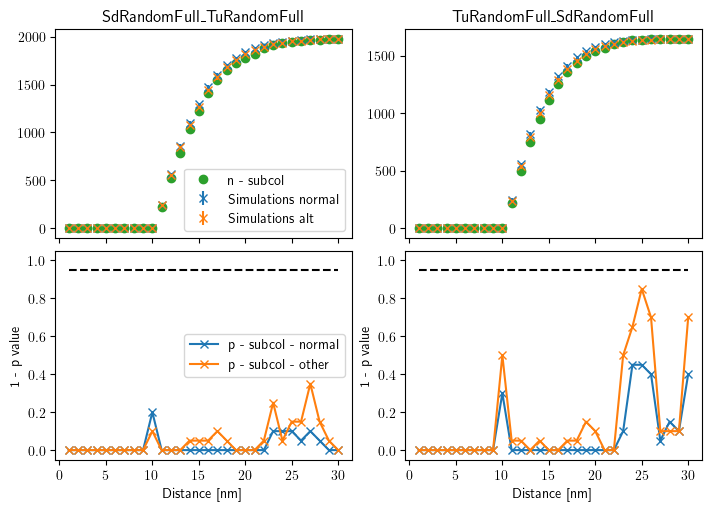

In [29]:
names = ['SdRandomFull_TuRandomFull', 'TuRandomFull_SdRandomFull']
tomos = None
single = False
normalize = False

n_columns = 2
fig_width = 7
fig_height_one = 2.5

fig, axes = plot_multiple(
    coloc=col, names=names, normalize=normalize, n_columns=n_columns, fig_width=fig_width, 
    fig_height_one=fig_height_one, tomos=tomos, single=single, names_inner=True);
#axes[0, 1].set_title('');

if plot_type == 'figure_save':
    axes[0, 0].set_title('')
    axes[0, 1].set_title('')
    axes[0, 0].set_ylabel('N colocalizations')
    axes[1, 1].set_ylabel('')
    axes[0, 0].get_legend().remove()
    #axes[0, 1].get_legend().remove()
    axes[1, 0].get_legend().remove()
    plt.savefig(plot_root + 'Sdf-Tuf.svg')

### Univariate

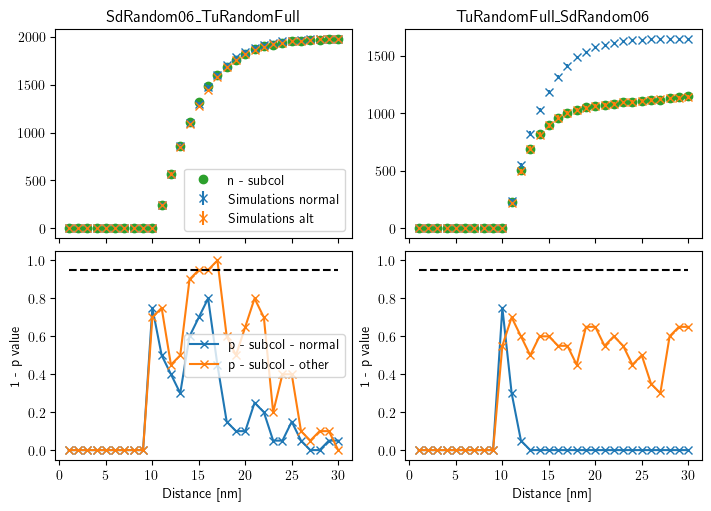

In [31]:
names = ['SdRandom06_TuRandomFull', 'TuRandomFull_SdRandom06']
tomos = None
single = False
normalize = False

n_columns = 2
fig_width = 7
fig_height_one = 2.5

fig, axes = plot_multiple(
    coloc=col, names=names, normalize=normalize, n_columns=n_columns, fig_width=fig_width, 
    fig_height_one=fig_height_one, tomos=tomos, single=single, names_inner=True);
#axes[0, 1].set_title('');

if plot_type == 'figure_save':
    axes[0, 0].set_title('')
    axes[0, 1].set_title('')
    axes[0, 0].set_ylabel('N colocalizations')
    axes[1, 1].set_ylabel('')
    axes[0, 0].get_legend().remove()
    #axes[0, 1].get_legend().remove()
    axes[1, 0].get_legend().remove()
    plt.savefig(plot_root + 'Sd06-Tuf.svg')

### Global interaction

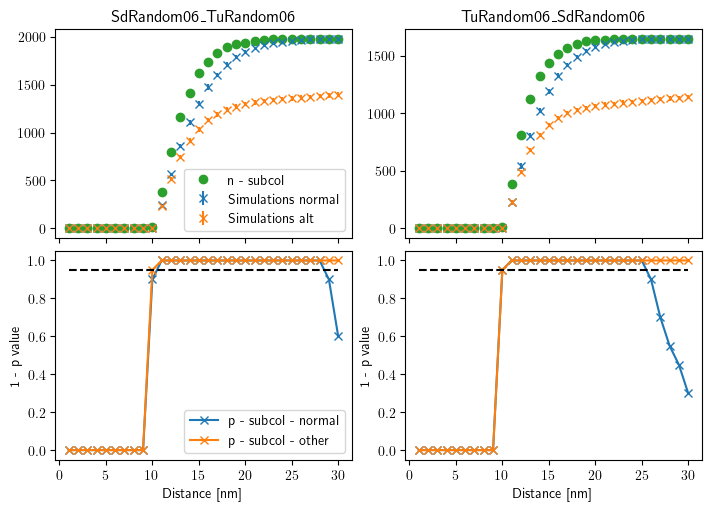

In [32]:
names = ['SdRandom06_TuRandom06', 'TuRandom06_SdRandom06']
tomos = None
single = False
normalize = False

n_columns = 2
fig_width = 7
fig_height_one = 2.5

fig, axes = plot_multiple(
    coloc=col, names=names, normalize=normalize, n_columns=n_columns, fig_width=fig_width, 
    fig_height_one=fig_height_one, tomos=tomos, single=single, names_inner=True);
#axes[0, 1].set_title('');

if plot_type == 'figure_save':
    axes[0, 0].set_title('')
    axes[0, 1].set_title('')
    axes[0, 0].set_ylabel('N colocalizations')
    axes[1, 1].set_ylabel('')
    axes[0, 0].get_legend().remove()
    #axes[0, 1].get_legend().remove()
    axes[1, 0].get_legend().remove()
    plt.savefig(plot_root + 'Sd06-Tu06.svg')

### Local interaction 1-to-1
1-to-1 is the same as kd

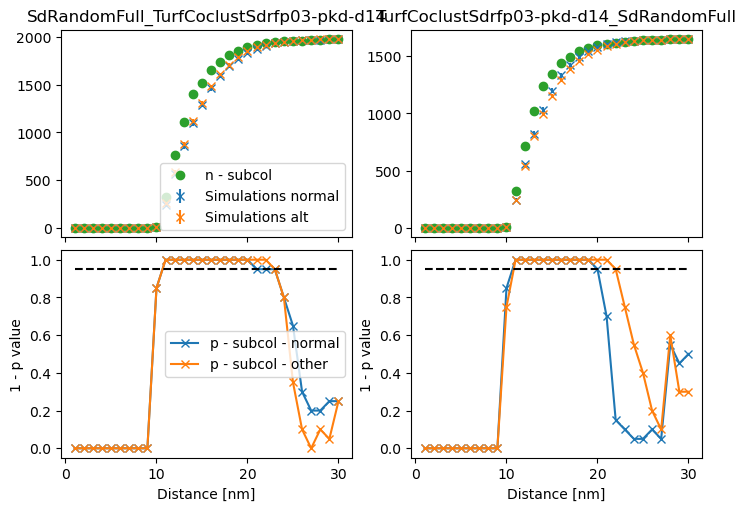

In [40]:
names = ['SdRandomFull_TurfCoclustSdrfp03-pkd-d14', 
         'TurfCoclustSdrfp03-pkd-d14_SdRandomFull']
tomos = None
single = False
normalize = False

n_columns = 2
fig_width = 7
fig_height_one = 2.5

fig, axes = plot_multiple(
    coloc=col, names=names, normalize=normalize, n_columns=n_columns, fig_width=fig_width, 
    fig_height_one=fig_height_one, tomos=tomos, single=single, names_inner=True);
#axes[0, 1].set_title('');

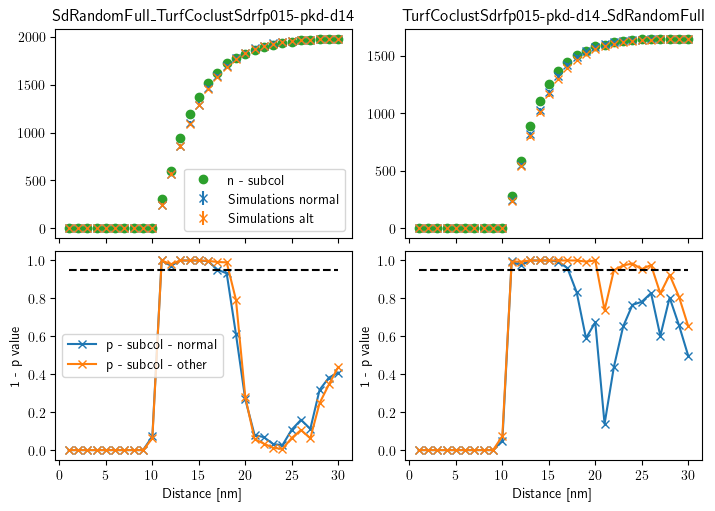

In [28]:
names = ['SdRandomFull_TurfCoclustSdrfp015-pkd-d14', 
         'TurfCoclustSdrfp015-pkd-d14_SdRandomFull']
tomos = None
single = False
normalize = False

n_columns = 2
fig_width = 7
fig_height_one = 2.5

fig, axes = plot_multiple(
    coloc=col_500, names=names, normalize=normalize, n_columns=n_columns, fig_width=fig_width, 
    fig_height_one=fig_height_one, tomos=tomos, single=single, names_inner=True);
#axes[0, 1].set_title('');
if plot_type == 'figure_save':
    axes[0, 0].set_title('')
    axes[0, 1].set_title('')
    axes[0, 0].set_ylabel('N colocalizations')
    axes[1, 1].set_ylabel('')
    axes[0, 0].get_legend().remove()
    #axes[0, 1].get_legend().remove()
    axes[1, 0].get_legend().remove()
    plt.savefig(plot_root + 'Sdrf-Tup15kd.svg')

### Local and global interaction 1-to-1
1-to-1 is the same as kd

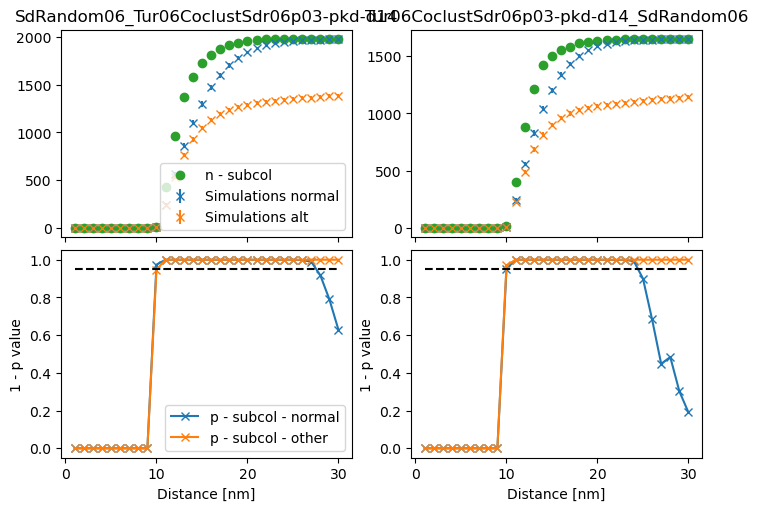

In [45]:
names = ['SdRandom06_Tur06CoclustSdr06p03-pkd-d14', 
         'Tur06CoclustSdr06p03-pkd-d14_SdRandom06']
tomos = None
single = False
normalize = False

n_columns = 2
fig_width = 7
fig_height_one = 2.5

fig, axes = plot_multiple(
    coloc=col, names=names, normalize=normalize, n_columns=n_columns, fig_width=fig_width, 
    fig_height_one=fig_height_one, tomos=tomos, single=single, names_inner=True);
#axes[0, 1].set_title('');

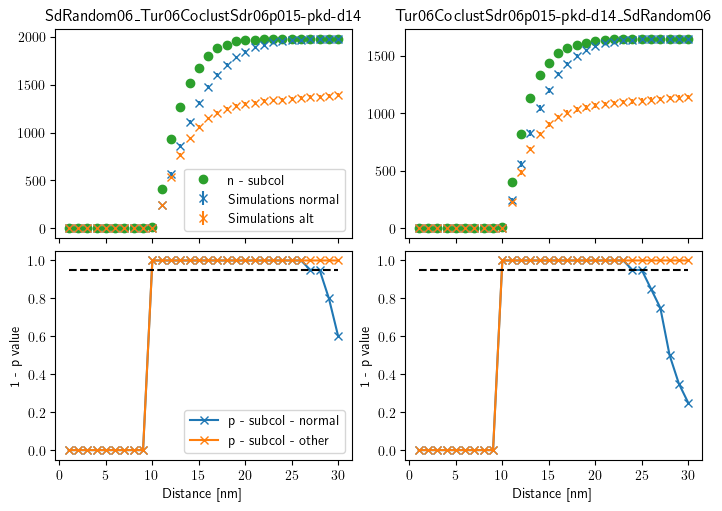

In [42]:
names = ['SdRandom06_Tur06CoclustSdr06p015-pkd-d14', 
         'Tur06CoclustSdr06p015-pkd-d14_SdRandom06']
tomos = None
single = False
normalize = False

n_columns = 2
fig_width = 7
fig_height_one = 2.5

fig, axes = plot_multiple(
    coloc=col, names=names, normalize=normalize, n_columns=n_columns, fig_width=fig_width, 
    fig_height_one=fig_height_one, tomos=tomos, single=single, names_inner=True);
#axes[0, 1].set_title('');
if plot_type == 'figure_save':
    axes[0, 0].set_title('')
    axes[0, 1].set_title('')
    axes[0, 0].set_ylabel('N colocalizations')
    axes[1, 1].set_ylabel('')
    axes[0, 0].get_legend().remove()
    #axes[0, 1].get_legend().remove()
    axes[1, 0].get_legend().remove()
    plt.savefig(plot_root + 'Sdr06-Tur06p15kd.svg')

## Accessing colocalization results

### Random

In [59]:
# get all data

names = ['SdRandomFull_TuRandomFull', 'TuRandomFull_SdRandomFull']

_, st_data = col.get_data(names[0])
_, ts_data = col.get_data(names[1])
print(f"All data column names: {st_data.columns}")
st_data.head()

All data column names: Index(['distance', 'id', 'n_subcol', 'n_SdRandomFull_subcol',
       'n_TuRandomFull_subcol', 'n_SdRandomFull_total', 'n_TuRandomFull_total',
       'size_region', 'n_col', 'size_col', 'n_subcol_random_all',
       'n_subcol_random_alt_all', 'n_subcol_random_mean',
       'n_subcol_random_std', 'n_subcol_random_alt_mean',
       'n_subcol_random_alt_std', 'n_subcol_random_combined_mean',
       'n_subcol_random_combined_std', 'n_SdRandomFull_subcol_random_all',
       'n_SdRandomFull_subcol_random_alt_all',
       'n_TuRandomFull_subcol_random_all',
       'n_TuRandomFull_subcol_random_alt_all', 'p_subcol_normal',
       'p_subcol_other', 'p_subcol_combined', 'pixel_nm'],
      dtype='object')


,distance,id,n_subcol,n_SdRandomFull_subcol,n_TuRandomFull_subcol,n_SdRandomFull_total,n_TuRandomFull_total,size_region,n_col,size_col,...,n_subcol_random_combined_mean,n_subcol_random_combined_std,n_SdRandomFull_subcol_random_all,n_SdRandomFull_subcol_random_alt_all,n_TuRandomFull_subcol_random_all,n_TuRandomFull_subcol_random_alt_all,p_subcol_normal,p_subcol_other,p_subcol_combined,pixel_nm
0,1,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1
1,2,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1
2,3,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1
3,4,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1
4,5,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1


In [62]:
# show select data for S-T
cols = ['distance', 'n_subcol', 'p_subcol_normal', 'p_subcol_other']
st_data.query('distance>=10 and distance <=20')[cols]

,distance,n_subcol,p_subcol_normal,p_subcol_other
9,10,5,0.2,0.10
10,11,219,0.0,0.00
11,12,520,0.0,0.00
12,13,790,0.0,0.00
13,14,1038,0.0,0.05
14,15,1229,0.0,0.05
15,16,1407,0.0,0.05
16,17,1545,0.0,0.10
17,18,1648,0.0,0.05
18,19,1725,0.0,0.00


In [63]:
# show select data for t-S
cols = ['distance', 'n_subcol', 'p_subcol_normal', 'p_subcol_other']
ts_data.query('distance>=10 and distance <=20')[cols]

,distance,n_subcol,p_subcol_normal,p_subcol_other
9,10,5,0.3,0.50
10,11,218,0.0,0.05
11,12,503,0.0,0.05
12,13,750,0.0,0.00
13,14,953,0.0,0.05
14,15,1114,0.0,0.00
15,16,1253,0.0,0.00
16,17,1362,0.0,0.05
17,18,1439,0.0,0.05
18,19,1504,0.0,0.15


### Local interaction 1-to-1

In [54]:
# get all data

names = ['SdRandomFull_TurfCoclustSdrfp015-pkd-d14', 
         'TurfCoclustSdrfp015-pkd-d14_SdRandomFull']

_, st_data = col_500.get_data(names[0])
_, ts_data = col_500.get_data(names[1])
print(f"All data column names: {st_data.columns}")
st_data.head()

All data column names: Index(['distance', 'id', 'n_subcol', 'n_SdRandomFull_subcol',
       'n_TurfCoclustSdrfp015-pkd-d14_subcol', 'n_SdRandomFull_total',
       'n_TurfCoclustSdrfp015-pkd-d14_total', 'size_region', 'n_col',
       'size_col', 'n_subcol_random_all', 'n_subcol_random_alt_all',
       'n_subcol_random_mean', 'n_subcol_random_std',
       'n_subcol_random_alt_mean', 'n_subcol_random_alt_std',
       'n_subcol_random_combined_mean', 'n_subcol_random_combined_std',
       'n_SdRandomFull_subcol_random_all',
       'n_SdRandomFull_subcol_random_alt_all',
       'n_TurfCoclustSdrfp015-pkd-d14_subcol_random_all',
       'n_TurfCoclustSdrfp015-pkd-d14_subcol_random_alt_all',
       'p_subcol_normal', 'p_subcol_other', 'p_subcol_combined', 'pixel_nm'],
      dtype='object')


,distance,id,n_subcol,n_SdRandomFull_subcol,n_TurfCoclustSdrfp015-pkd-d14_subcol,n_SdRandomFull_total,n_TurfCoclustSdrfp015-pkd-d14_total,size_region,n_col,size_col,...,n_subcol_random_combined_mean,n_subcol_random_combined_std,n_SdRandomFull_subcol_random_all,n_SdRandomFull_subcol_random_alt_all,n_TurfCoclustSdrfp015-pkd-d14_subcol_random_all,n_TurfCoclustSdrfp015-pkd-d14_subcol_random_alt_all,p_subcol_normal,p_subcol_other,p_subcol_combined,pixel_nm
0,1,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1
1,2,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1
2,3,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1
3,4,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1
4,5,delta,0,0,0,1980,1650,528120,0,0,...,0.0,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0,0.0,0.0,1


In [55]:
# show select data for S-T
cols = ['distance', 'n_subcol', 'p_subcol_normal', 'p_subcol_other']
st_data.query('distance>=10 and distance <=20')[cols]

,distance,n_subcol,p_subcol_normal,p_subcol_other
9,10,3,0.072,0.062
10,11,304,1.000,1.000
11,12,603,0.972,0.980
12,13,948,1.000,1.000
13,14,1198,1.000,1.000
14,15,1375,1.000,1.000
15,16,1513,0.996,0.998
16,17,1626,0.952,0.992
17,18,1725,0.932,0.990
18,19,1780,0.610,0.792


In [56]:
# show select data for t-S
cols = ['distance', 'n_subcol', 'p_subcol_normal', 'p_subcol_other']
ts_data.query('distance>=10 and distance <=20')[cols]

,distance,n_subcol,p_subcol_normal,p_subcol_other
9,10,3,0.050,0.074
10,11,284,0.996,0.994
11,12,589,0.974,0.994
12,13,890,1.000,1.000
13,14,1106,1.000,1.000
14,15,1257,1.000,1.000
15,16,1372,0.994,1.000
16,17,1446,0.960,1.000
17,18,1506,0.832,1.000
18,19,1545,0.590,0.994


## Visualize patterns

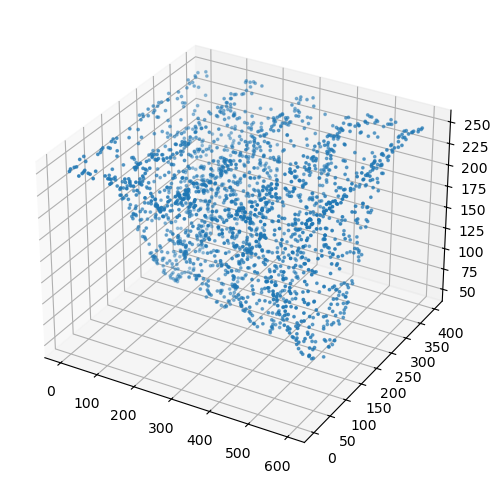

In [74]:
pattern_name = 'SdRandomFull'

fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')

parts = mps.particles.query('class_name == @pattern_name')[[
    'x_reg_frame', 'y_reg_frame', 'z_reg_frame']].to_numpy()
ax.scatter(parts[:, 0], parts[:, 1], parts[:, 2], s=3)

#ax.set_ylim(200, 220)

In [36]:
# definitions

colors = {'S': 'm', 'T': 'c'}

def plot_pattern_curved(
    mps, pattern_names, y_slices, y_thick, xlim, zlim, 
    n_cols, colors, row_height=3, figwidth=9, legend=False):
    """Plots point patterns for curved 3D domains
    """

    n_rows = (len(y_slices) - 1) // n_cols + 1
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(figwidth, n_rows*row_height), layout='constrained', 
        sharex=True, sharey=True)

    for ax, y_sl in zip(axes.flat, y_slices):
    
        for nam in pattern_names:
            parts = mps.particles.query('class_name == @nam')[[
                'x_reg_frame', 'y_reg_frame', 'z_reg_frame']].to_numpy()
            cond = (parts[:, 1] >= y_sl) & (parts[:, 1] < y_sl+y_thick) 
            parts_slice = parts[cond]
            ax.scatter(
                parts_slice[:, 0], parts_slice[:, 2], s=3, color=colors[nam[0]])

        ax.set_title(f'y: {y_sl}-{y_sl+y_thick}')
        ax.set_xlabel('x')
        ax.set_ylabel('z')
        if legend:
            ax.legend(pattern_names)
        ax.set_xlim(xlim)
        ax.set_ylim(zlim)

    return fig, axes

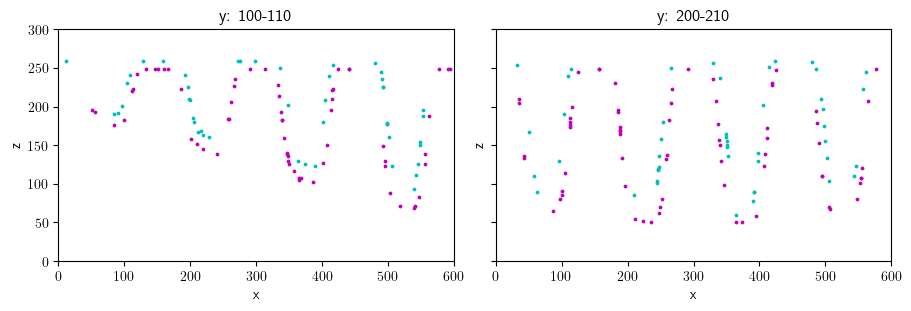

In [37]:
pattern_names = ['SdRandomFull', 'TuRandomFull']
y_slices = (100, 150, 200, 250)
y_slices = (100, 200)
y_thick = 10
xlim = (0, 600)
zlim = (0, 300)

n_cols = 2
row_height = 3.5
figwidth = 9

_, axes = plot_pattern_curved(
    mps=mps, pattern_names=pattern_names, y_slices=y_slices, 
    y_thick=y_thick, xlim=xlim, zlim=zlim, 
    n_cols=n_cols, colors=colors, row_height=3, figwidth=9, legend=False)
if plot_type == 'figure_save':
    plt.savefig(plot_root + 'Sdrf-Turf_particles.svg', bbox_inches='tight')

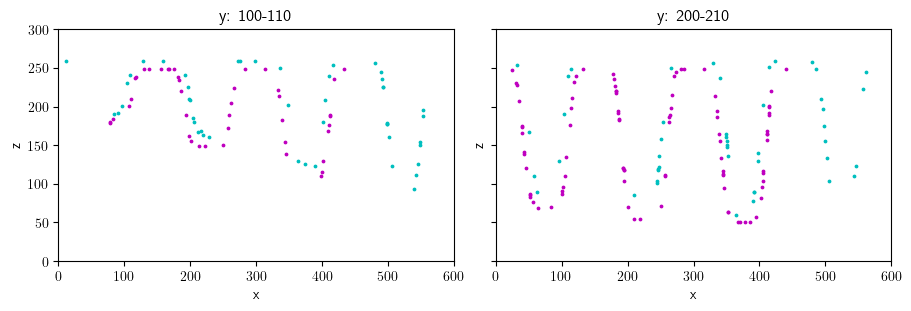

In [38]:
pattern_names = ['SdRandom06', 'TuRandomFull']
y_slices = (100, 150, 200, 250)
y_slices = (100, 200)
y_thick = 10
xlim = (0, 600)
zlim = (0, 300)

n_cols = 2
row_height = 3
figwidth = 9

_, axes = plot_pattern_curved(
    mps=mps, pattern_names=pattern_names, y_slices=y_slices, 
    y_thick=y_thick, xlim=xlim, zlim=zlim, 
    n_cols=n_cols, colors=colors, row_height=3, figwidth=9, legend=False)
if plot_type == 'figure_save':
    plt.savefig(plot_root + 'Sd06-Turf_particles.svg', bbox_inches='tight')

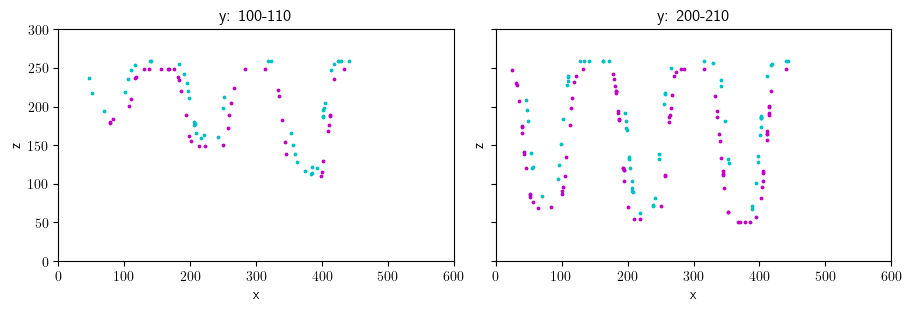

In [39]:
pattern_names = ['SdRandom06', 'TuRandom06']
y_slices = (100, 150, 200, 250)
y_slices = (100, 200)
y_thick = 10
xlim = (0, 600)
zlim = (0, 300)

n_cols = 2
row_height = 3
figwidth = 9

_, axes = plot_pattern_curved(
    mps=mps, pattern_names=pattern_names, y_slices=y_slices, 
    y_thick=y_thick, xlim=xlim, zlim=zlim, 
    n_cols=n_cols, colors=colors, row_height=3, figwidth=9, legend=False)
if plot_type == 'figure_save':
    plt.savefig(plot_root + 'Sd06-Tu06_particles.svg', bbox_inches='tight')

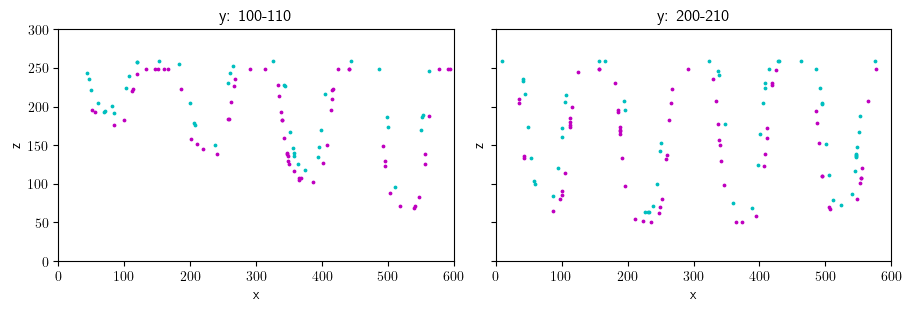

In [40]:
pattern_names = ['SdRandomFull', 'TurfCoclustSdrfp015-pkd-d14']
y_slices = (100, 150, 200, 250)
y_slices = (100, 200)
y_thick = 10
xlim = (0, 600)
zlim = (0, 300)

n_cols = 2
row_height = 3
figwidth = 9

_, axes = plot_pattern_curved(
    mps=mps, pattern_names=pattern_names, y_slices=y_slices, 
    y_thick=y_thick, xlim=xlim, zlim=zlim, 
    n_cols=n_cols, colors=colors, row_height=3, figwidth=9, legend=False)
if plot_type == 'figure_save':
    plt.savefig(plot_root + 'Sdrf-Turf-15kd_particles.svg', bbox_inches='tight')

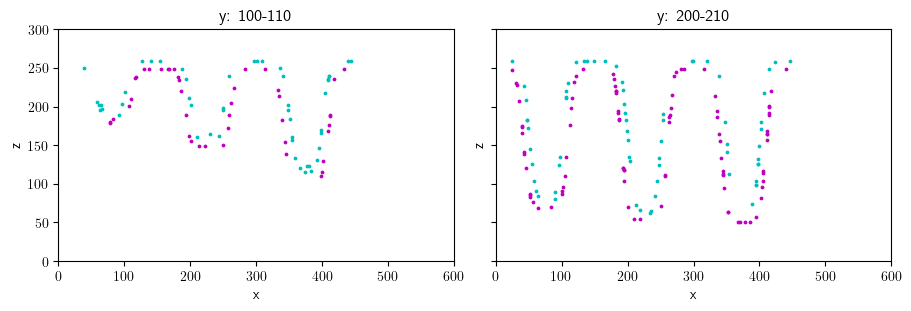

In [41]:
pattern_names = ['SdRandom06', 'Tur06CoclustSdr06p015-pkd-d14']
y_slices = (100, 150, 200, 250)
y_slices = (100, 200)
y_thick = 10
xlim = (0, 600)
zlim = (0, 300)

n_cols = 2
row_height = 3
figwidth = 9

_, axes = plot_pattern_curved(
    mps=mps, pattern_names=pattern_names, y_slices=y_slices, 
    y_thick=y_thick, xlim=xlim, zlim=zlim, 
    n_cols=n_cols, colors=colors, row_height=3, figwidth=9, legend=False)
if plot_type == 'figure_save':
    plt.savefig(plot_root + 'Sd06-Tu06-15kd_particles.svg', bbox_inches='tight')